# Grouped Bar Chart

## Setup:

In [3]:
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import re

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['mathtext.fontset'] = 'cm'

# Load results
RESULTS_PATH = 'gcn_results.json'  # Update path as needed
with open(RESULTS_PATH, 'r') as f:
    results = json.load(f)

print(f"Loaded {len(results)} entries")

Loaded 192 entries


## Parse Results:

In [4]:
DATASETS = ['AIDS', 'Letter-low', 'MNIST', 'MUTAG', 'PTC_FM', 'Synthie', 'NCI1', 'Tox21_AhR_training']
DS_DISPLAY = {
    'AIDS': 'AIDS', 'Letter-low': 'Letter-low', 'MNIST': 'MNIST',
    'MUTAG': 'MUTAG', 'PTC_FM': 'PTC_FM', 'Synthie': 'Synthie',
    'NCI1': 'NCI1', 'Tox21_AhR_training': 'Tox21',
}

METHODS = ['Random', 'Non-boundary', 'EGSteal-BB', 'Boundary', 'Hybrid']
SEEDS = ['42', '123', '456']

def get_key(ds, method, exp, seed):
    return f'{ds}_GCN_{method}_{exp}_70pct_seed{seed}'

def get_fidelities(ds, method, exp_code):
    """Get fidelity values across all seeds for a dataset/method/explainer combo."""
    exp = 'none' if method in ['Random', 'Non-boundary'] else exp_code
    fids = []
    for seed in SEEDS:
        k = get_key(ds, method, exp, seed)
        if k in results:
            fids.append(results[k]['fidelity'] * 100)
    return fids

# Verify data availability
for exp_code in ['GNN', 'PG']:
    print(f"\n=== {exp_code} ===")
    for ds in DATASETS:
        for method in METHODS:
            fids = get_fidelities(ds, method, exp_code)
            if len(fids) < 3:
                print(f"  INCOMPLETE: {ds} {method} ({exp_code}): {len(fids)} seeds")
    print("  All complete" if True else "")


=== GNN ===
  All complete

=== PG ===
  All complete


## Bar Chart (GNNExplainer):

Saved bar_fidelity_GNN.pdf


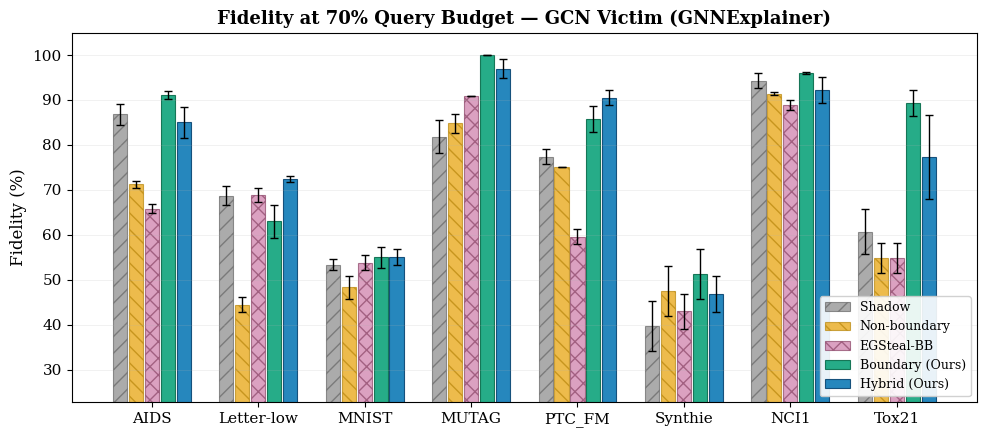

In [6]:
def make_bar_chart(exp_code, filename=None, show=True, save=True):
    """Grouped bar chart: datasets on x-axis, methods as bars, error bars from 3 seeds."""

    method_colors = {
        'Random':       '#888888',
        'Non-boundary': '#E69F00',
        'EGSteal-BB':   '#CC79A7',
        'Boundary':     '#009E73',
        'Hybrid':       '#0072B2',
    }
    method_labels = {
        'Random': 'Shadow',
        'Non-boundary': 'Non-boundary',
        'EGSteal-BB': 'EGSteal-BB',
        'Boundary': 'Boundary (Ours)',
        'Hybrid': 'Hybrid (Ours)',
    }
    # Hatch for baselines, solid for ours
    method_hatch = {
        'Random': '//',
        'Non-boundary': '\\\\',
        'EGSteal-BB': 'xx',
        'Boundary': '',
        'Hybrid': '',
    }
    method_edge = {
        'Random': '#666666',
        'Non-boundary': '#b8860b',
        'EGSteal-BB': '#8b4567',
        'Boundary': '#006644',
        'Hybrid': '#003d6b',
    }

    n_datasets = len(DATASETS)
    n_methods = len(METHODS)
    bar_width = 0.15
    x = np.arange(n_datasets)

    fig, ax = plt.subplots(figsize=(10, 4.5))

    for j, method in enumerate(METHODS):
        means, stds = [], []
        for ds in DATASETS:
            fids = get_fidelities(ds, method, exp_code)
            if fids:
                means.append(np.mean(fids))
                stds.append(np.std(fids))
            else:
                means.append(0)
                stds.append(0)

        offset = (j - (n_methods - 1) / 2) * bar_width
        bars = ax.bar(x + offset, means, bar_width * 0.88,
                      yerr=stds, capsize=3,
                      color=method_colors[method],
                      edgecolor=method_edge[method],
                      hatch=method_hatch[method],
                      linewidth=0.8,
                      error_kw={'linewidth': 1.0, 'capthick': 1.0},
                      label=method_labels[method],
                      alpha=0.85 if method in ['Boundary', 'Hybrid'] else 0.7)

    exp_label = 'GNNExplainer' if exp_code == 'GNN' else 'PGExplainer'
    ax.set_ylabel('Fidelity (%)', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([DS_DISPLAY[ds] for ds in DATASETS], fontsize=11)
    ax.legend(fontsize=9, loc='lower right', framealpha=0.9)
    ax.grid(True, axis='y', alpha=0.25, linewidth=0.5)
    ax.set_title(f'Fidelity at 70% Query Budget — GCN Victim ({exp_label})',
                 fontsize=13, fontweight='bold')

    # Dynamic y-axis: start slightly below min
    all_vals = []
    for method in METHODS:
        for ds in DATASETS:
            all_vals.extend(get_fidelities(ds, method, exp_code))
    if all_vals:
        y_min = max(0, min(all_vals) - 10)
        ax.set_ylim(bottom=y_min)

    plt.tight_layout()
    if save and filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved {filename}")
    if show:
        plt.show()
    else:
        plt.close()

make_bar_chart('GNN', filename='bar_fidelity_GNN.pdf')

## Bar Chart (PGExplainer):

Saved bar_fidelity_PG.pdf


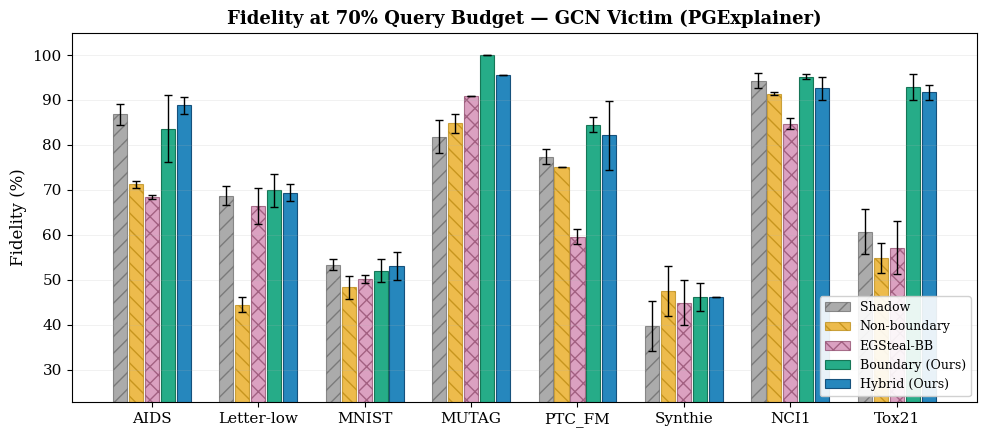

In [7]:
make_bar_chart('PG', filename='bar_fidelity_PG.pdf')

## Combined Bar Chart (Both Explainers Side-by-Side):

Saved bar_fidelity_combined.pdf


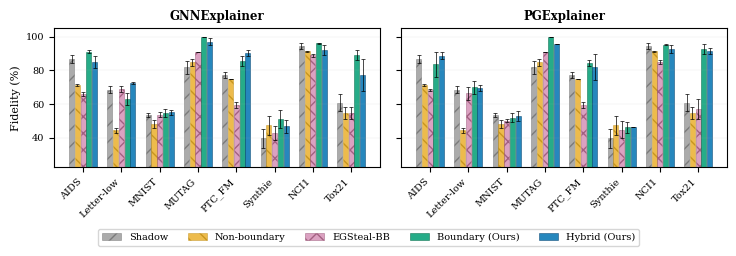

In [11]:
def make_combined_bar_chart(filename=None, show=True, save=True):
    """Two-panel bar chart: GNNExplainer (left) and PGExplainer (right)."""

    method_colors = {
        'Random':       '#888888',
        'Non-boundary': '#E69F00',
        'EGSteal-BB':   '#CC79A7',
        'Boundary':     '#009E73',
        'Hybrid':       '#0072B2',
    }
    method_labels = {
        'Random': 'Shadow',
        'Non-boundary': 'Non-boundary',
        'EGSteal-BB': 'EGSteal-BB',
        'Boundary': 'Boundary (Ours)',
        'Hybrid': 'Hybrid (Ours)',
    }
    method_hatch = {
        'Random': '//',
        'Non-boundary': '\\\\',
        'EGSteal-BB': 'xx',
        'Boundary': '',
        'Hybrid': '',
    }
    method_edge = {
        'Random': '#666666',
        'Non-boundary': '#b8860b',
        'EGSteal-BB': '#8b4567',
        'Boundary': '#006644',
        'Hybrid': '#003d6b',
    }

    n_datasets = len(DATASETS)
    n_methods = len(METHODS)
    bar_width = 0.15
    x = np.arange(n_datasets)

    # Print-size: ~7.5" wide to match NeurIPS \textwidth, ~2.5" tall
    fig, axes = plt.subplots(1, 2, figsize=(7.5, 2.5), sharey=True)

    for panel_idx, (exp_code, exp_label) in enumerate([('GNN', 'GNNExplainer'), ('PG', 'PGExplainer')]):
        ax = axes[panel_idx]

        for j, method in enumerate(METHODS):
            means, stds = [], []
            for ds in DATASETS:
                fids = get_fidelities(ds, method, exp_code)
                if fids:
                    means.append(np.mean(fids))
                    stds.append(np.std(fids))
                else:
                    means.append(0)
                    stds.append(0)

            offset = (j - (n_methods - 1) / 2) * bar_width
            ax.bar(x + offset, means, bar_width * 0.88,
                   yerr=stds, capsize=1.5,
                   color=method_colors[method],
                   edgecolor=method_edge[method],
                   hatch=method_hatch[method],
                   linewidth=0.4,
                   error_kw={'linewidth': 0.5, 'capthick': 0.5},
                   label=method_labels[method] if panel_idx == 0 else None,
                   alpha=0.85 if method in ['Boundary', 'Hybrid'] else 0.7)

        ax.set_title(exp_label, fontsize=8.5, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([DS_DISPLAY[ds] for ds in DATASETS], fontsize=7, rotation=45, ha='right')
        ax.tick_params(labelsize=7)
        ax.grid(True, axis='y', alpha=0.25, linewidth=0.3)
        if panel_idx == 0:
            ax.set_ylabel('Fidelity (%)', fontsize=8)

    # Dynamic y-axis
    all_vals = []
    for exp_code in ['GNN', 'PG']:
        for method in METHODS:
            for ds in DATASETS:
                all_vals.extend(get_fidelities(ds, method, exp_code))
    if all_vals:
        y_min = max(0, min(all_vals) - 10)
        axes[0].set_ylim(bottom=y_min)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=n_methods,
               fontsize=7, bbox_to_anchor=(0.5, -0.03), frameon=True,
               fancybox=True, edgecolor='#cccccc', facecolor='white')

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    if save and filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved {filename}")
    if show:
        plt.show()
    else:
        plt.close()

make_combined_bar_chart(filename='bar_fidelity_combined.pdf')